## Multiple class ROC an AUC

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, StandardScaler
from sklearn.linear_model import LogisticRegression,LinearRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.svm import SVC


In [ ]:
df = pd.read_csv('data/bodyPerformance.csv')
df.head(n = 2)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A


## Check null data

In [3]:
df.isna().sum()

age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

In [4]:
df['class'].value_counts()

class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64

In [5]:
df['gender'].value_counts()

gender
M    8467
F    4926
Name: count, dtype: int64

In [6]:
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])

In [7]:
df.head(n =2)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A


## Split data to train vs test

In [8]:
X = df.drop(columns='class')
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 2026)

In [9]:
df.describe()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,0.632196,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,0.482226,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,0.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,0.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,1.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,1.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,1.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [10]:
df.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm', 'class'],
      dtype='object')

## Scale data using Standar Scaler

In [11]:
col_cont = ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm']

In [12]:
scaler = StandardScaler()
X_train[col_cont] = scaler.fit_transform(X_train[col_cont])
X_test[col_cont] = scaler.transform(X_test[col_cont])

## Build model

In [13]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr.score(X_train, y_train), lr.score(X_test, y_test)

(0.6182795698924731, 0.6234696924455061)

In [14]:
y_score = lr.predict_proba(X_test)
y_score

array([[0.66120622, 0.26889613, 0.06772386, 0.00217378],
       [0.0051249 , 0.14577365, 0.45166784, 0.39743361],
       [0.11581371, 0.47832281, 0.35878632, 0.04707716],
       ...,
       [0.00163565, 0.06308759, 0.27304704, 0.66222972],
       [0.30746383, 0.45468328, 0.22798875, 0.00986414],
       [0.53538868, 0.37456884, 0.08737666, 0.00266583]], shape=(3349, 4))

In [15]:
binarizer = LabelBinarizer()
y_true = binarizer.fit_transform(y_test)
y_true

array([[0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 1, 0, 0],
       ...,
       [0, 0, 0, 1],
       [0, 1, 0, 0],
       [1, 0, 0, 0]], shape=(3349, 4))

In [16]:
labels = sorted(df['class'].unique())

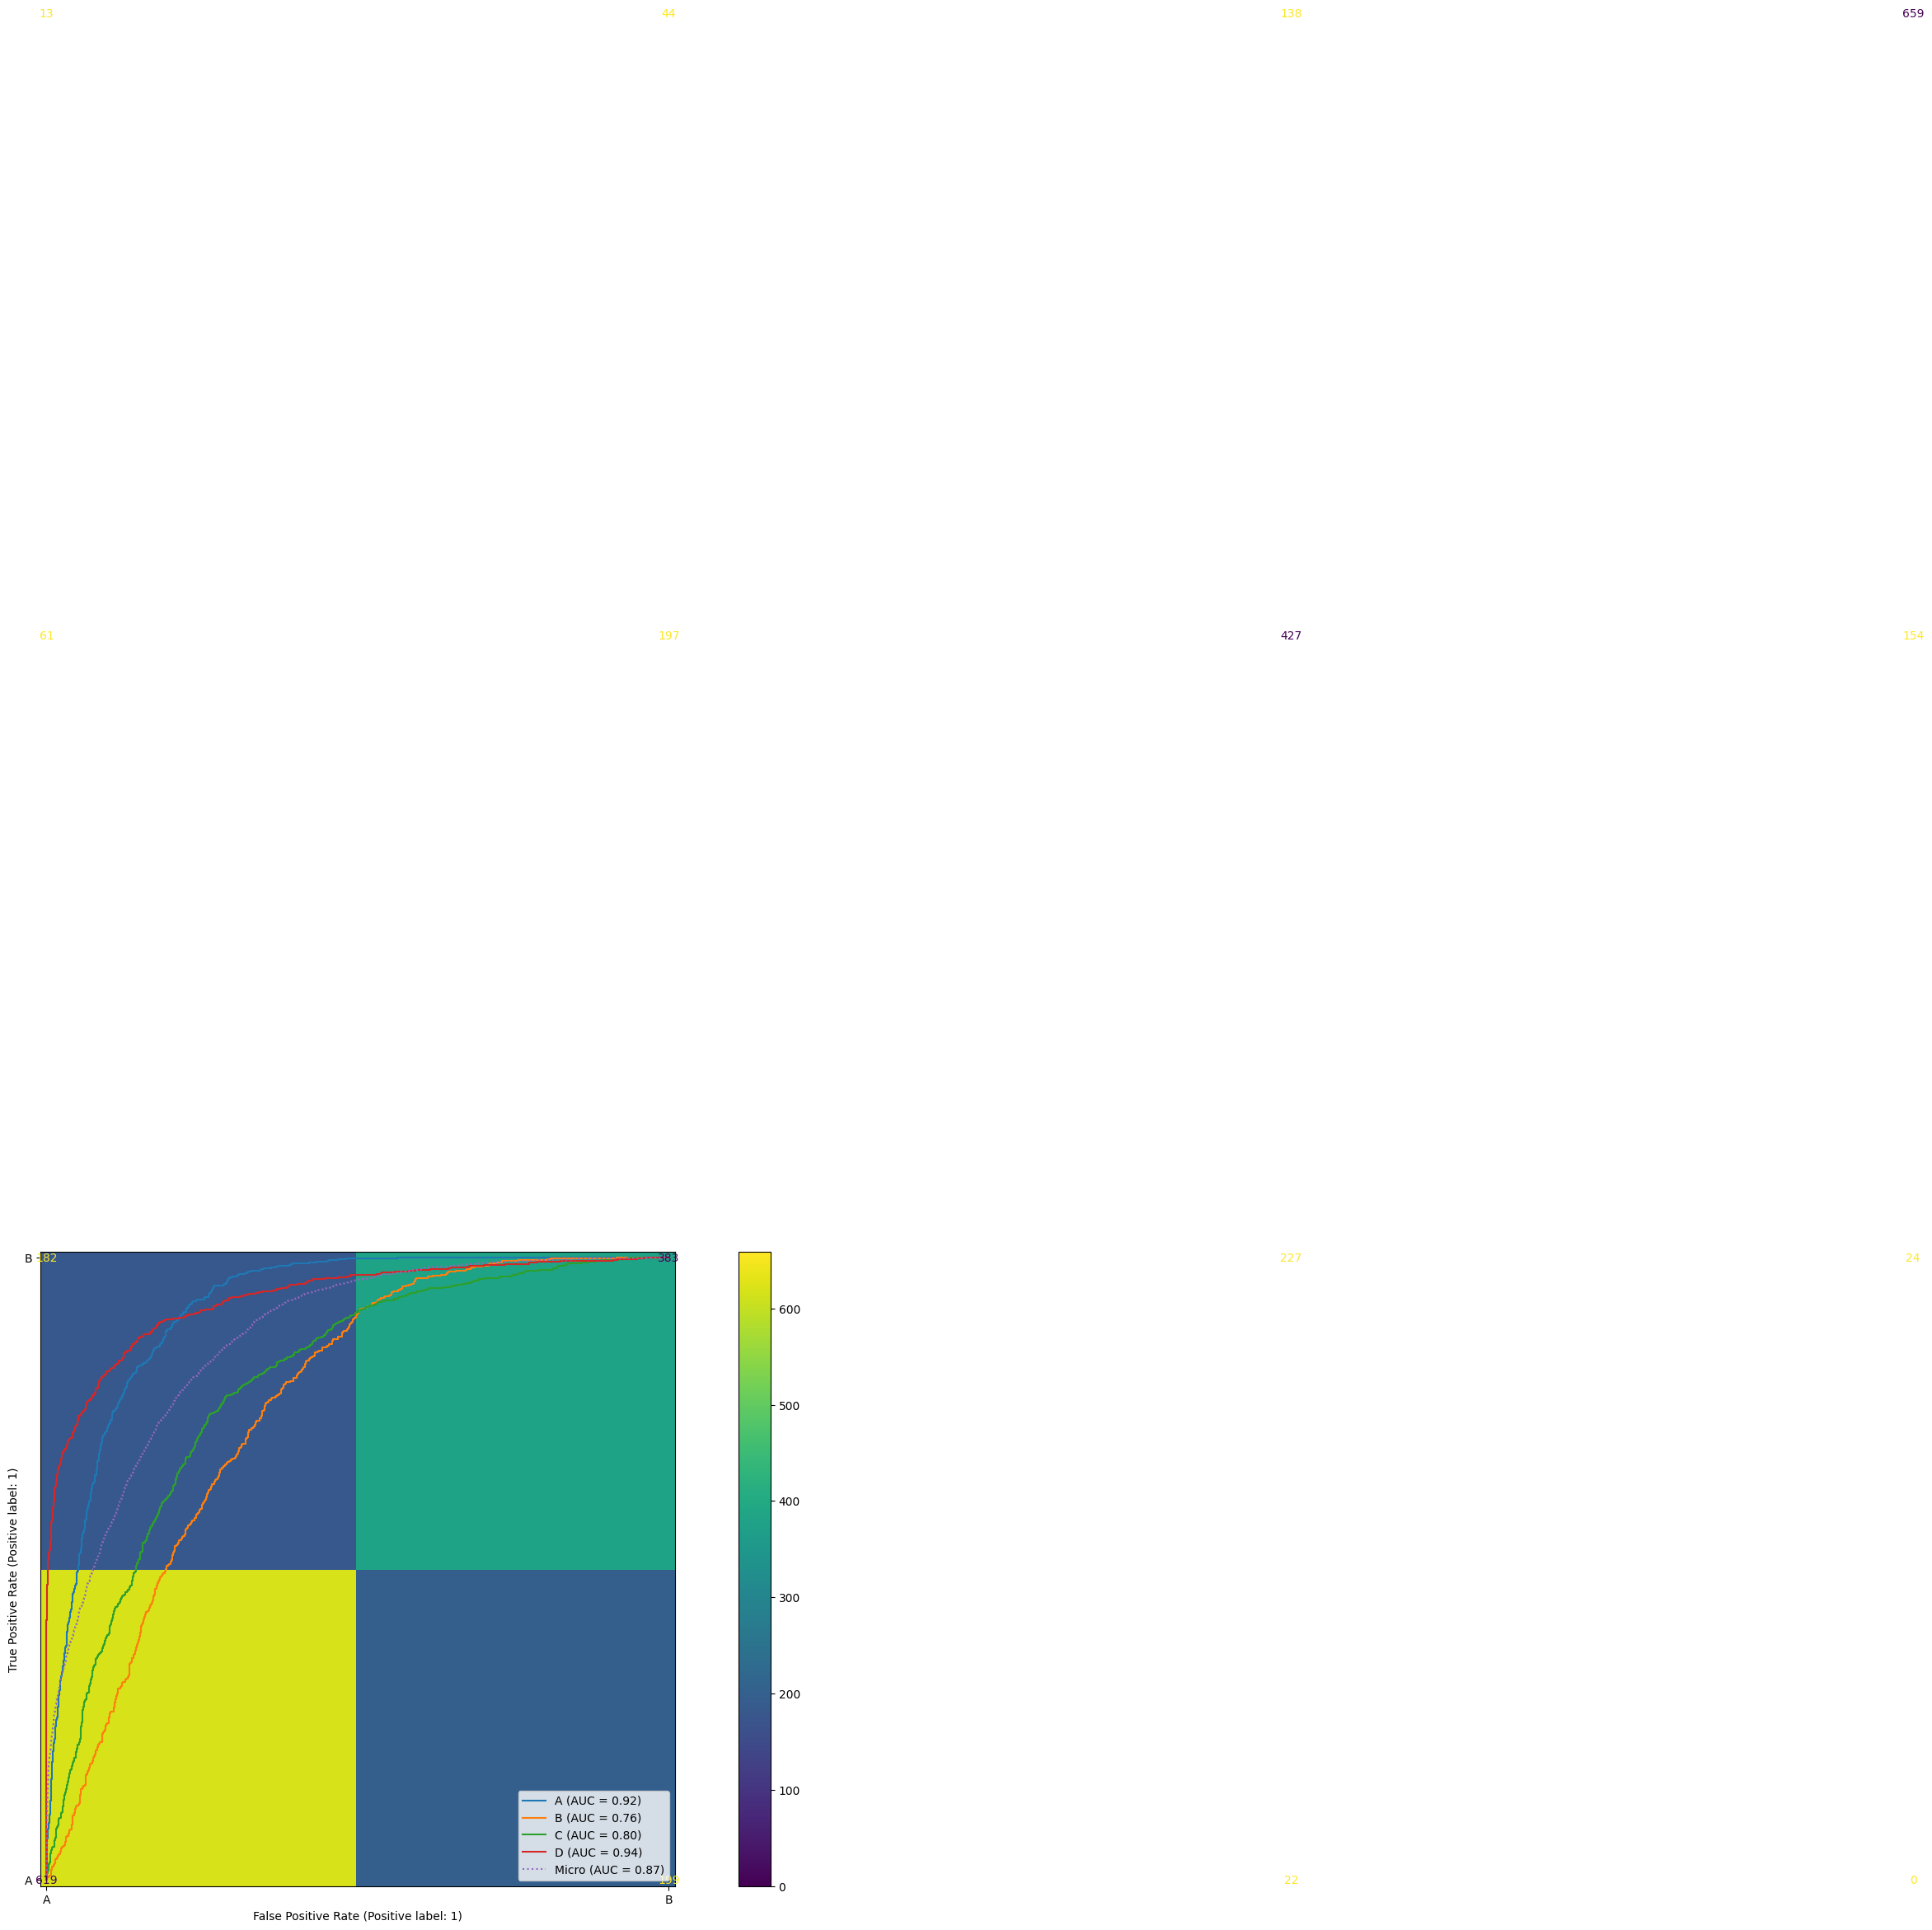

In [18]:
n = y_true.shape[1]
fig, ax = plt.subplots(figsize = (20, 10))
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, ax =ax)
for i in range(n):
    RocCurveDisplay.from_predictions(y_true[:, i], y_score[:, i], ax = ax, name=labels[i])
RocCurveDisplay.from_predictions(y_true.ravel(), y_score.ravel(), ax = ax, name = 'Micro', curve_kwargs={'linestyle': ':'})
plt.show()

## micro

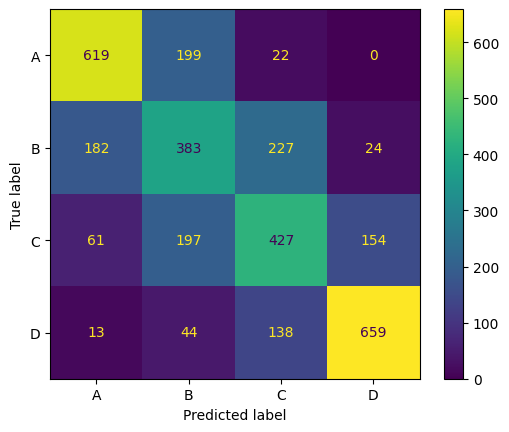

In [19]:
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

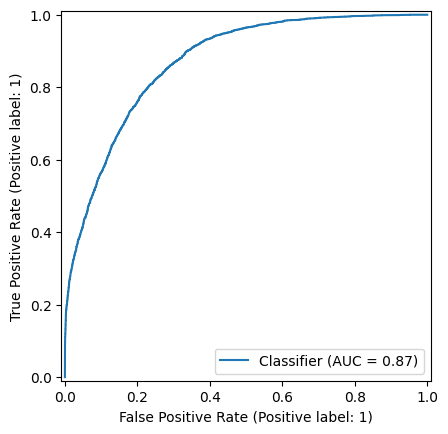

In [20]:
RocCurveDisplay.from_predictions(y_true.ravel(), y_score.ravel())
plt.show()

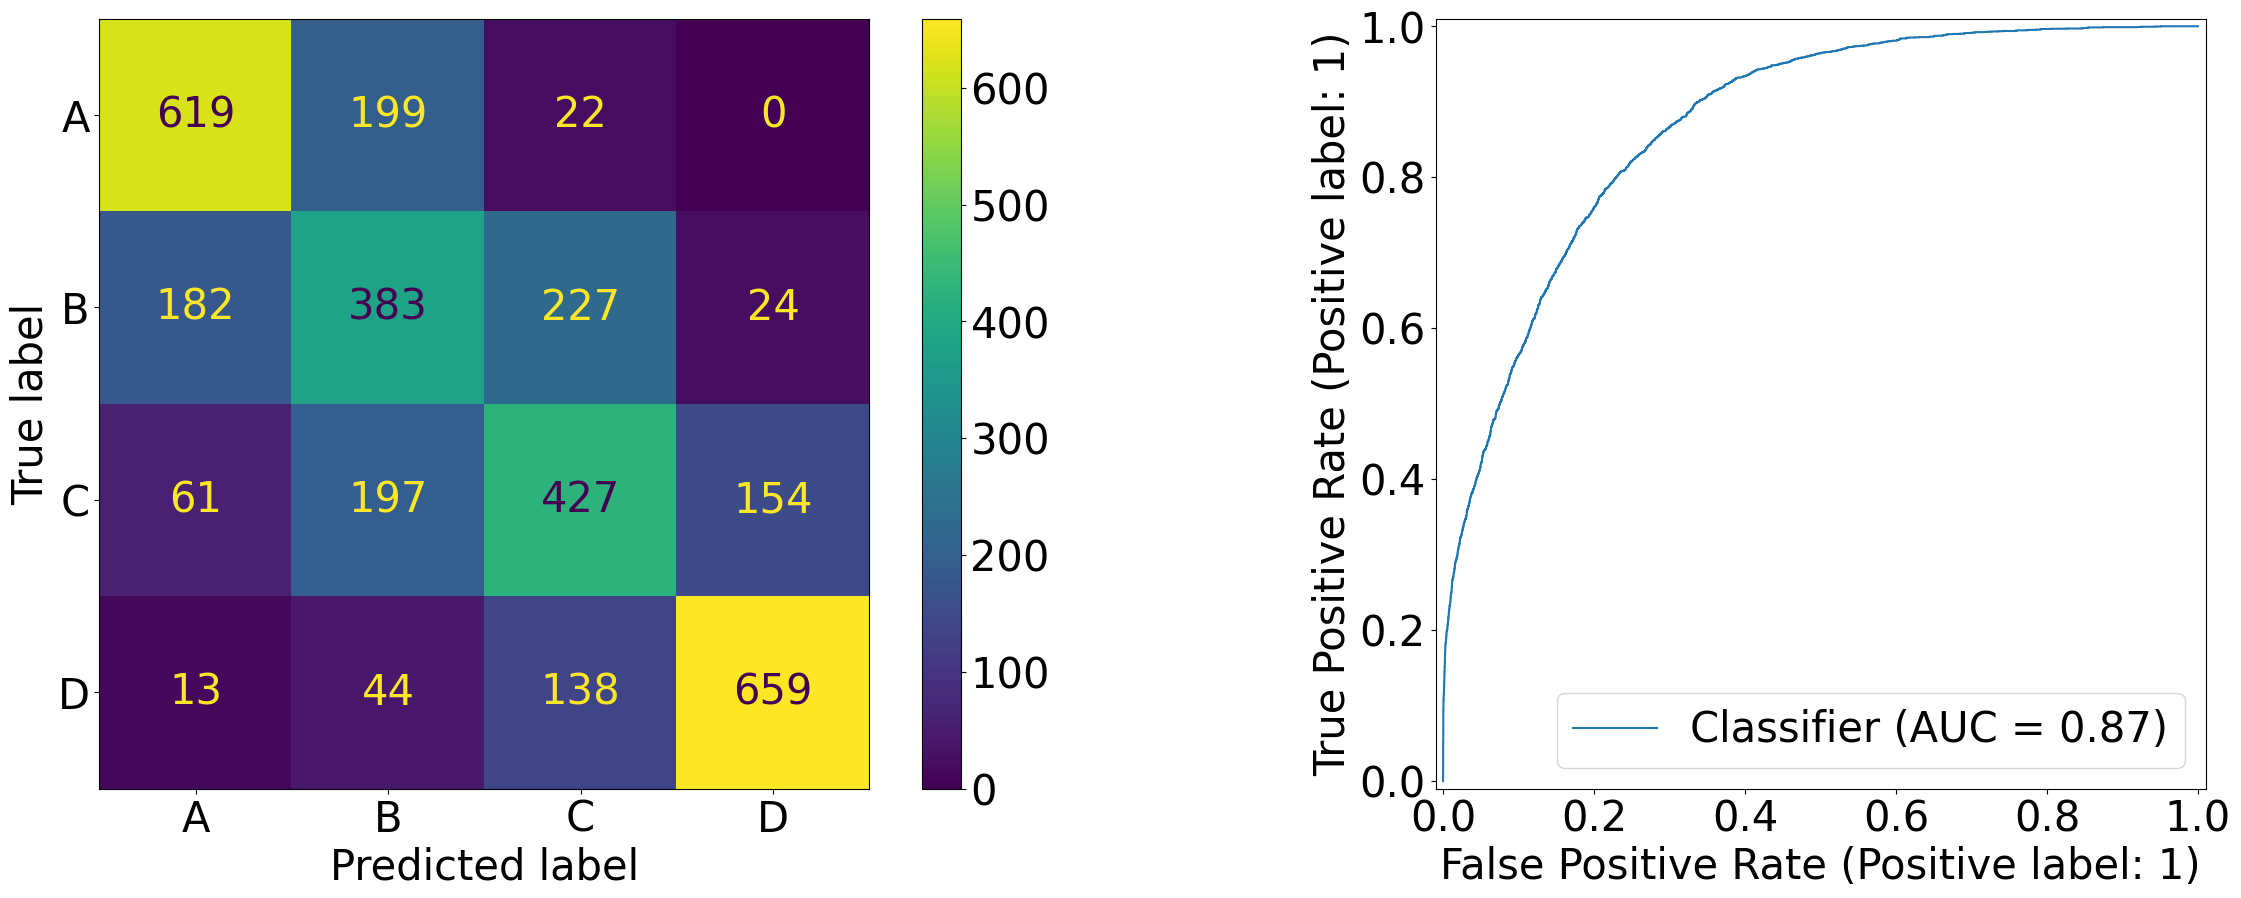

In [21]:
plt.rcParams['font.size'] = 30
fig, axes = plt.subplots(ncols=2, figsize=(30, 10))
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, ax=axes[0])
RocCurveDisplay.from_predictions(y_true.ravel(), y_score.ravel(), ax=axes[1])
plt.show()

In [22]:
sgd = SGDClassifier(loss= 'log_loss')
sgd.fit(X_train, y_train)
sgd.score(X_train, y_train), sgd.score(X_test, y_test)

(0.5869175627240143, 0.5804717826216781)

In [23]:
mlp = MLPClassifier(max_iter=500)
mlp.fit(X_train, y_train)
mlp.score(X_train, y_train), mlp.score(X_test, y_test)

(0.7934090003982477, 0.7351448193490594)

In [28]:
encoder = LabelEncoder()
y_train_label = encoder.fit_transform(y_train)
y_test_label = encoder.fit_transform(y_test)

In [29]:
y_train_label, y_test_label

(array([2, 2, 0, ..., 0, 0, 1], shape=(10044,)),
 array([3, 2, 1, ..., 3, 1, 0], shape=(3349,)))

In [30]:
svc = SVC(probability = True)
svc.fit(X_train, y_train)
svc.score(X_train, y_train), svc.score(X_test, y_test)

(0.7222222222222222, 0.6933412959092267)

In [31]:
knr = KNeighborsClassifier()
knr.fit(X_train, y_train)
knr.score(X_train, y_train), knr.score(X_test, y_test)

(0.720131421744325, 0.5933114362496268)

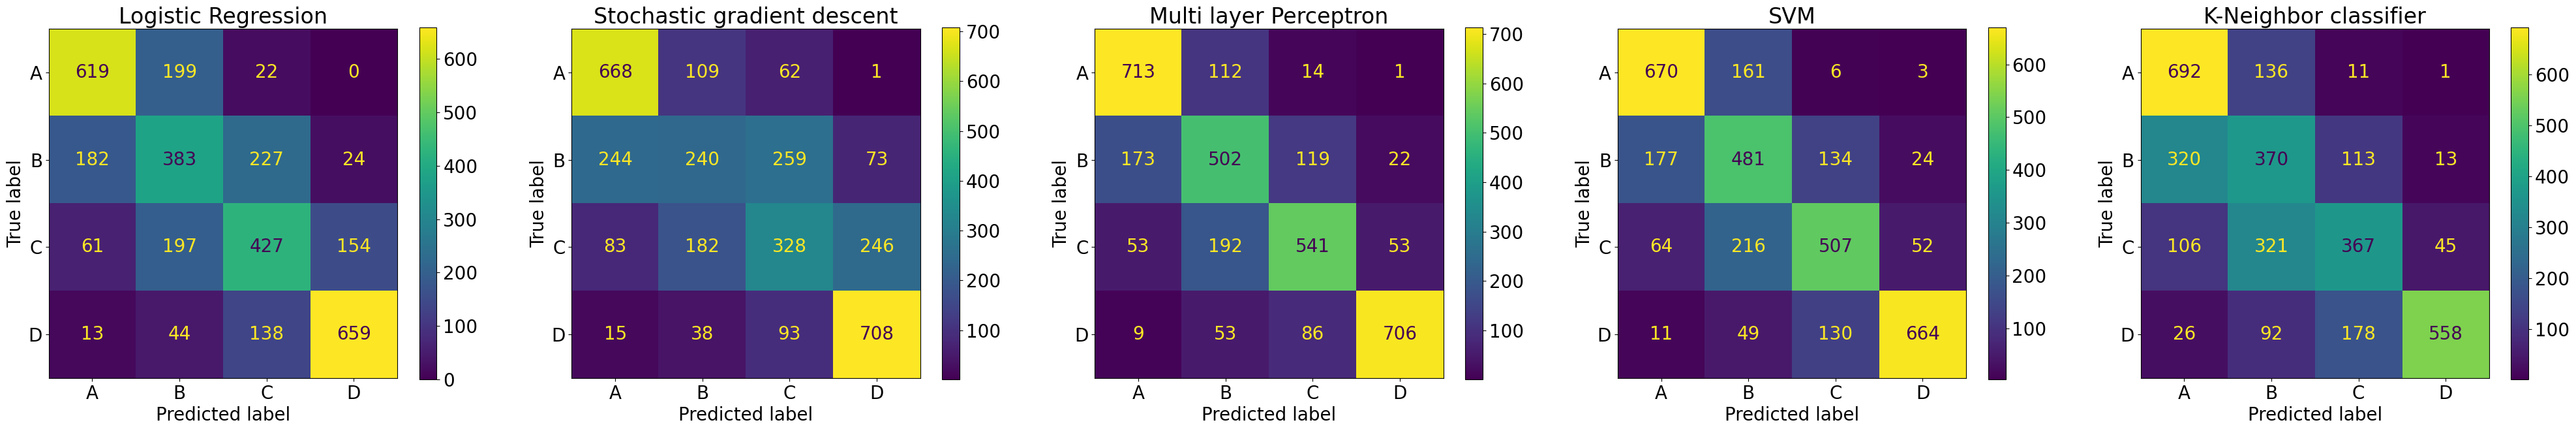

In [32]:
models = {
    'Logistic Regression': lr,
    'Stochastic gradient descent': sgd,
    'Multi layer Perceptron': mlp,
    'SVM': svc,
    'K-Neighbor classifier': knr
}
plt.rcParams['font.size'] = 20
fig, axes = plt.subplots(ncols=len(models), figsize = (50, 7))
for i, name in enumerate(models):
    ConfusionMatrixDisplay.from_estimator(models[name], X_test, y_test, ax = axes[i])
    axes[i].set_title(name)
plt.show()

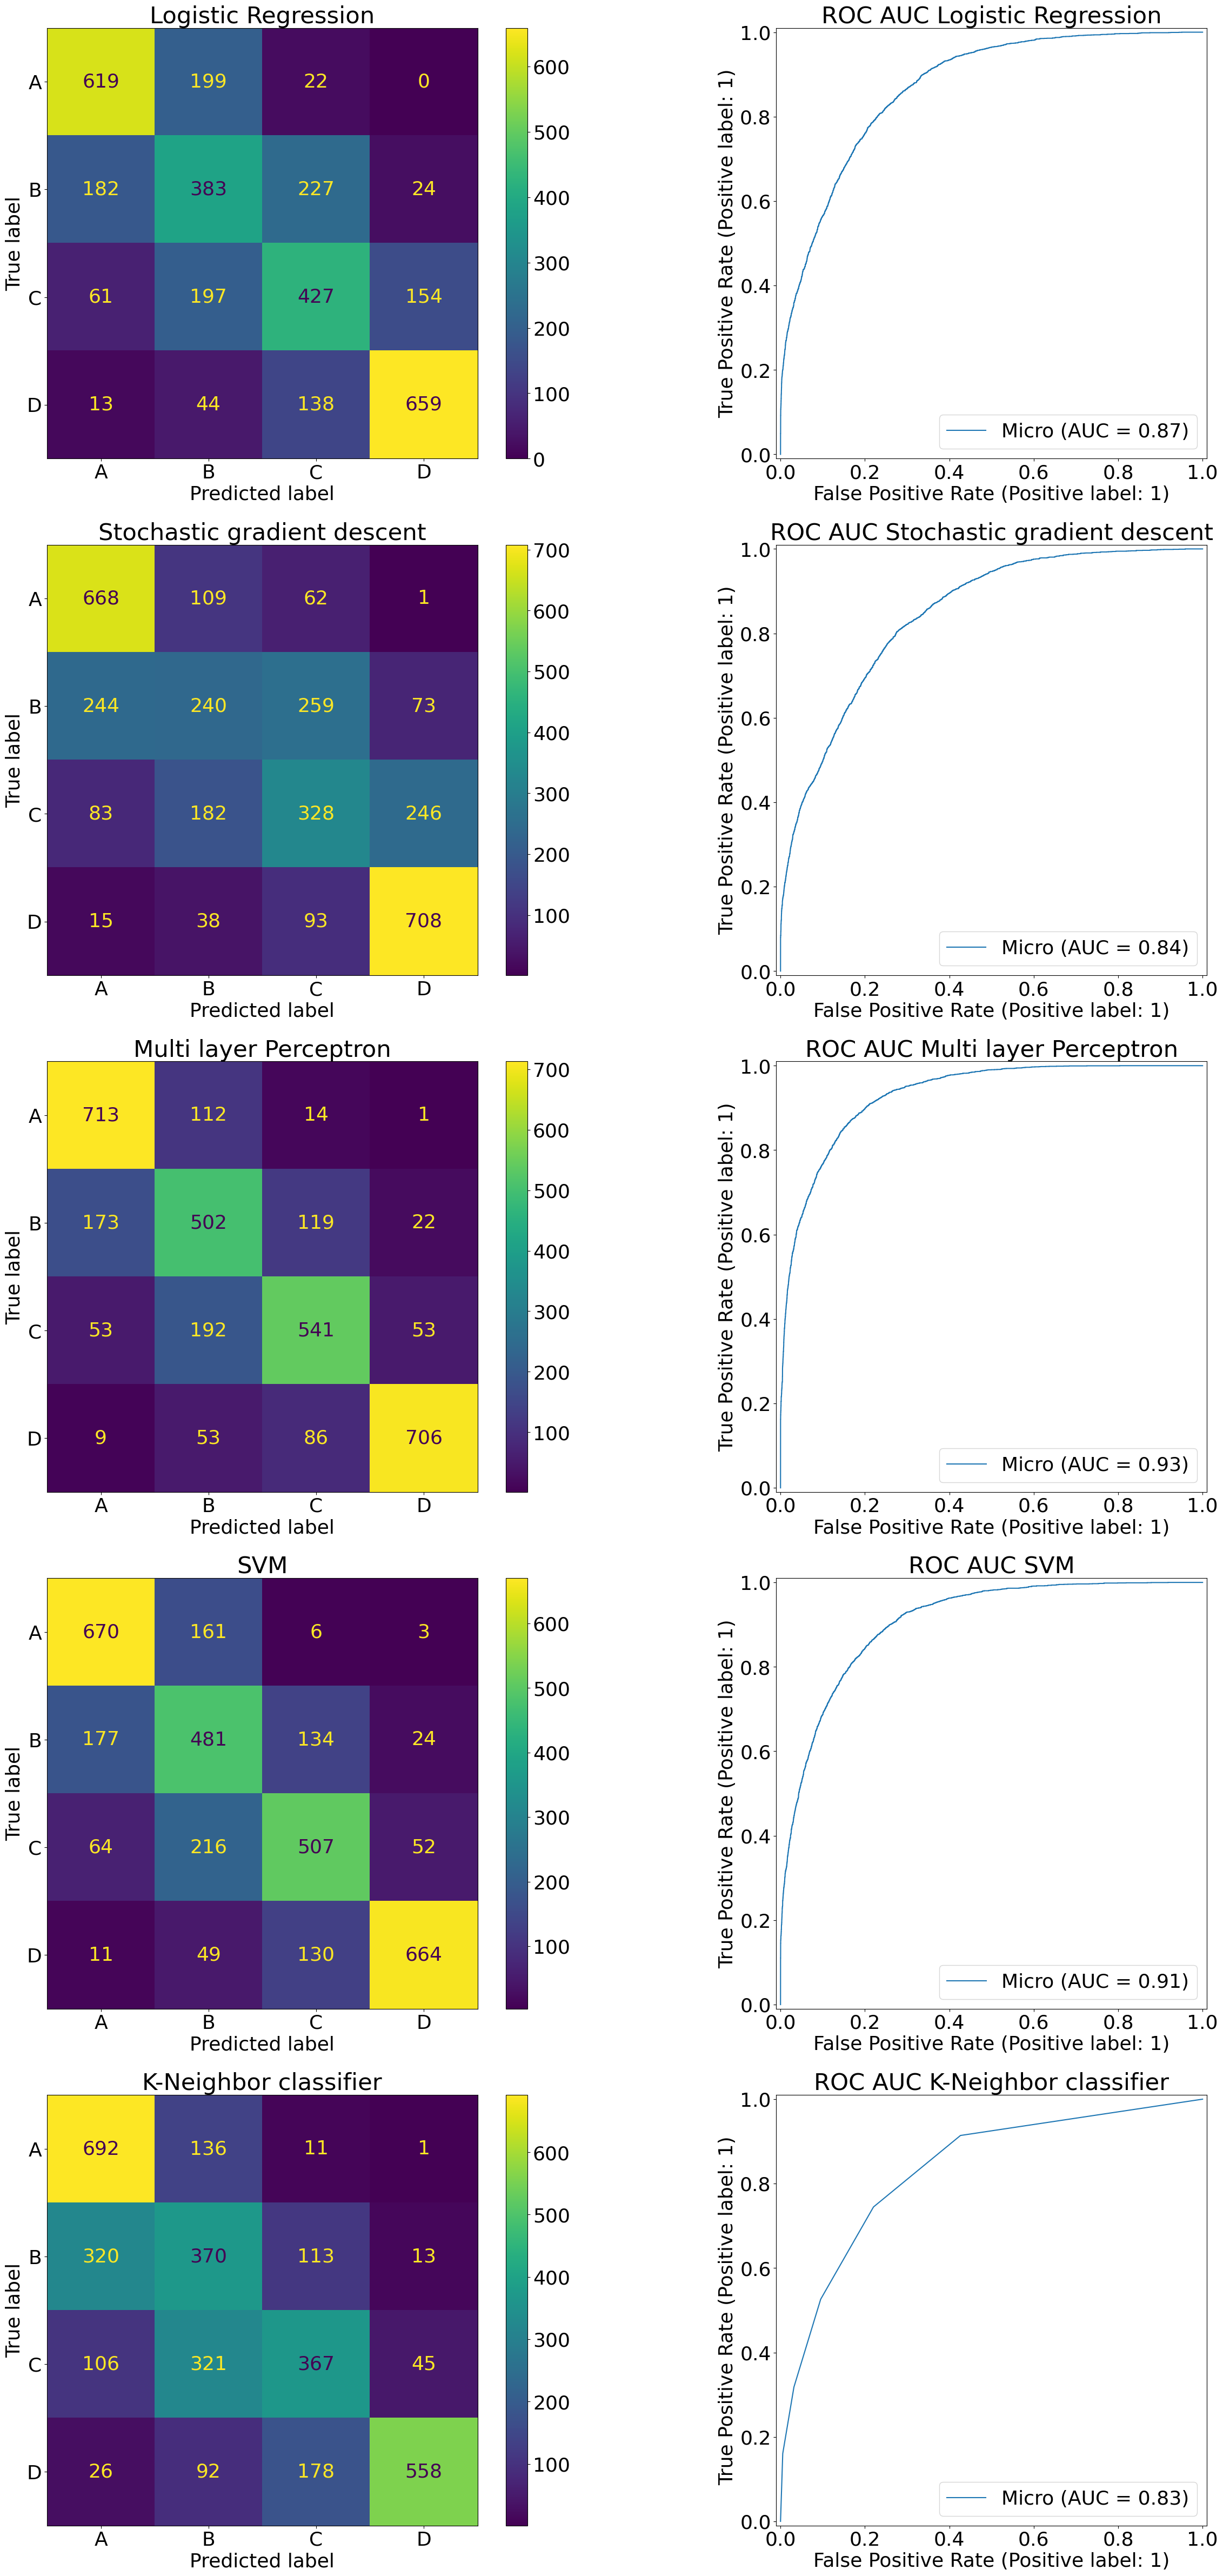

In [33]:
models = {
    'Logistic Regression': lr,
    'Stochastic gradient descent': sgd,
    'Multi layer Perceptron': mlp,
    'SVM': svc,
    'K-Neighbor classifier': knr
}
plt.rcParams['font.size'] = 26
fig, axes = plt.subplots(ncols = 2, nrows=len(models), figsize = (30, 60))
for i, name in enumerate(models):
    ConfusionMatrixDisplay.from_estimator(models[name], X_test, y_test, ax = axes[i][0])
    axes[i][0].set_title(name)
    y_score = models[name].predict_proba(X_test)
    axes[i][1].set_title(f'ROC AUC {name}')
    RocCurveDisplay.from_predictions(y_true.ravel(), y_score.ravel(), name = 'Micro', ax = axes[i][1])
plt.show()

In [19]:
mat = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
a = mat.flatten()
b = mat.ravel()

In [20]:
a[0] = 999
a, mat

(array([999,   2,   3,   4,   5,   6]),
 array([[1, 2, 3],
        [4, 5, 6]]))

In [22]:
b[0] = 8888
mat, b

(array([[8888,    2,    3],
        [   4,    5,    6]]),
 array([8888,    2,    3,    4,    5,    6]))

## Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

In [36]:
data1 =pd.DataFrame([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
], columns=['x1', 'x2', 'y'])
data1

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [ ]:
X = data1[['x1', 'x2']]
y = data1['y']
dtc = DecisionTreeClassifier()
dtc.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

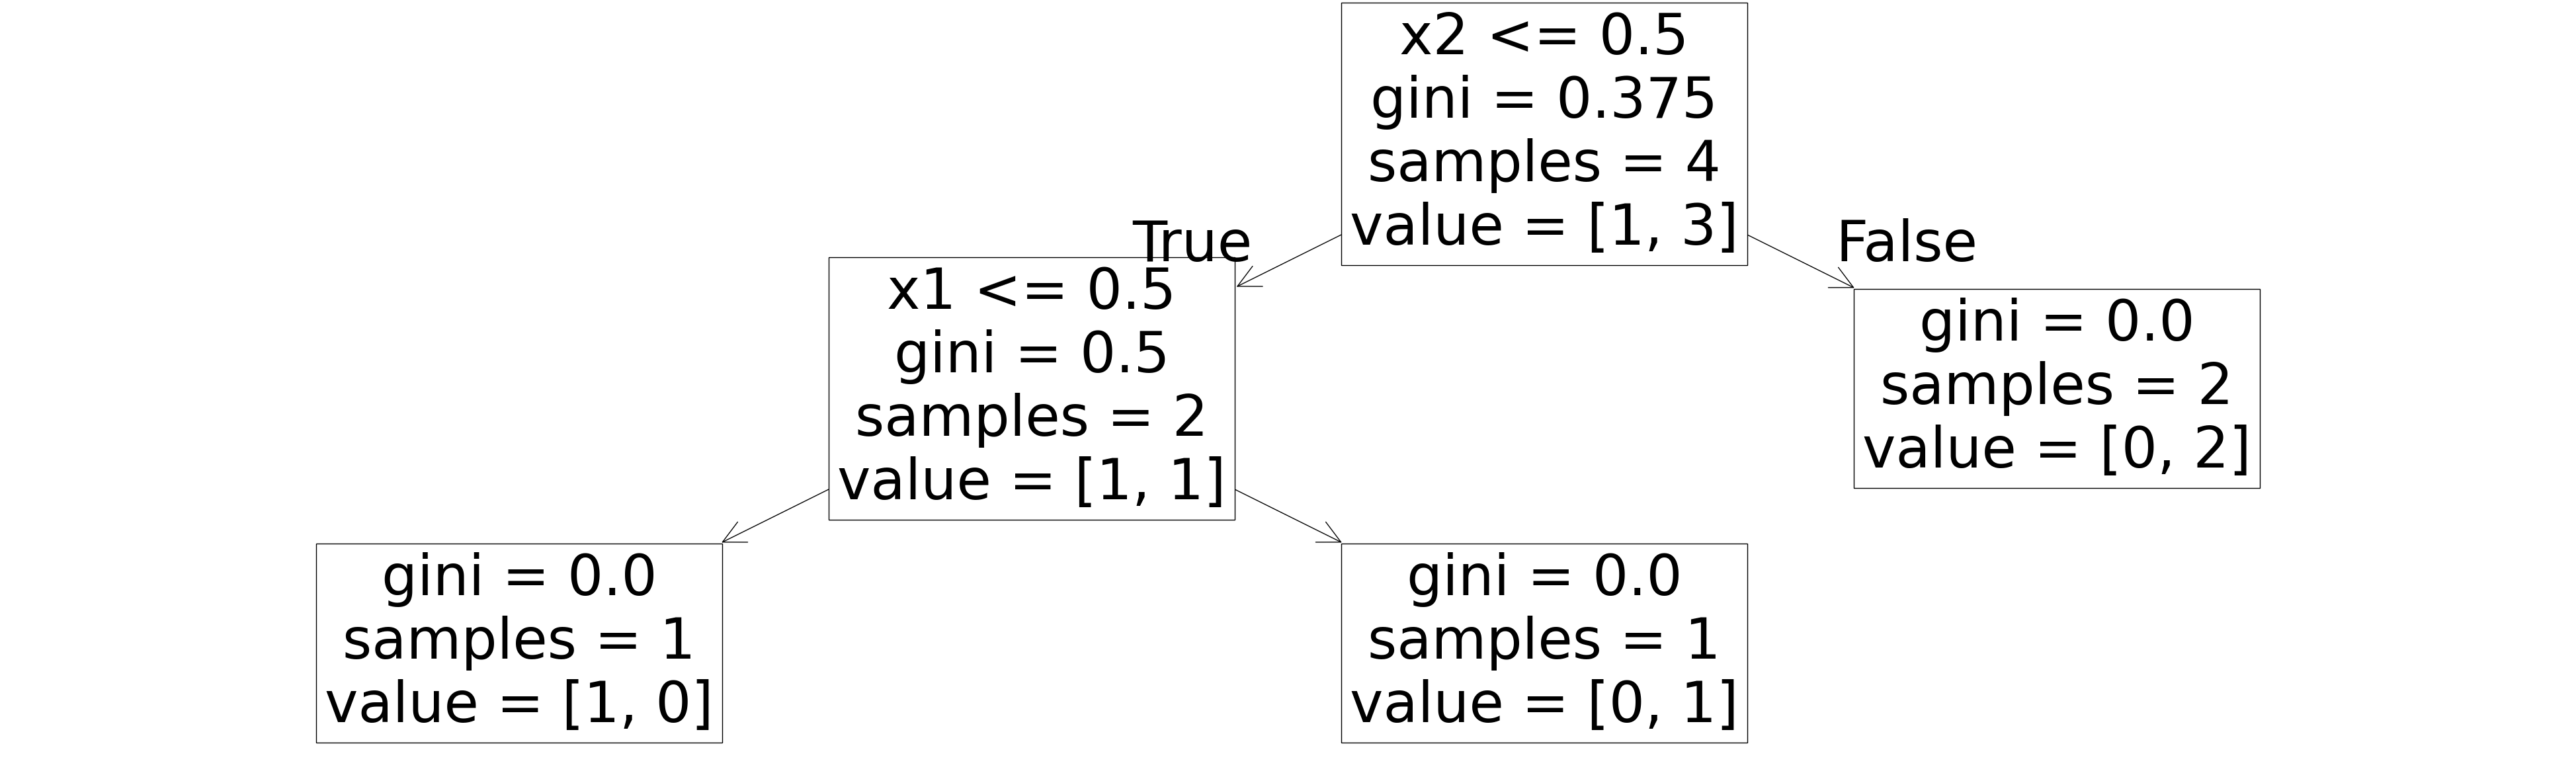

In [38]:
fig, ax = plt.subplots(figsize = (50, 15))
plot_tree(dtc, feature_names=['x1', 'x2'], ax=ax)
plt.show()

In [40]:
# E2
data1 =pd.DataFrame([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
], columns=['x1', 'x2', 'y'])
data1

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [ ]:
X = data1[['x1', 'x2']]
y = data1['y']
dtc = DecisionTreeClassifier()
dtc.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

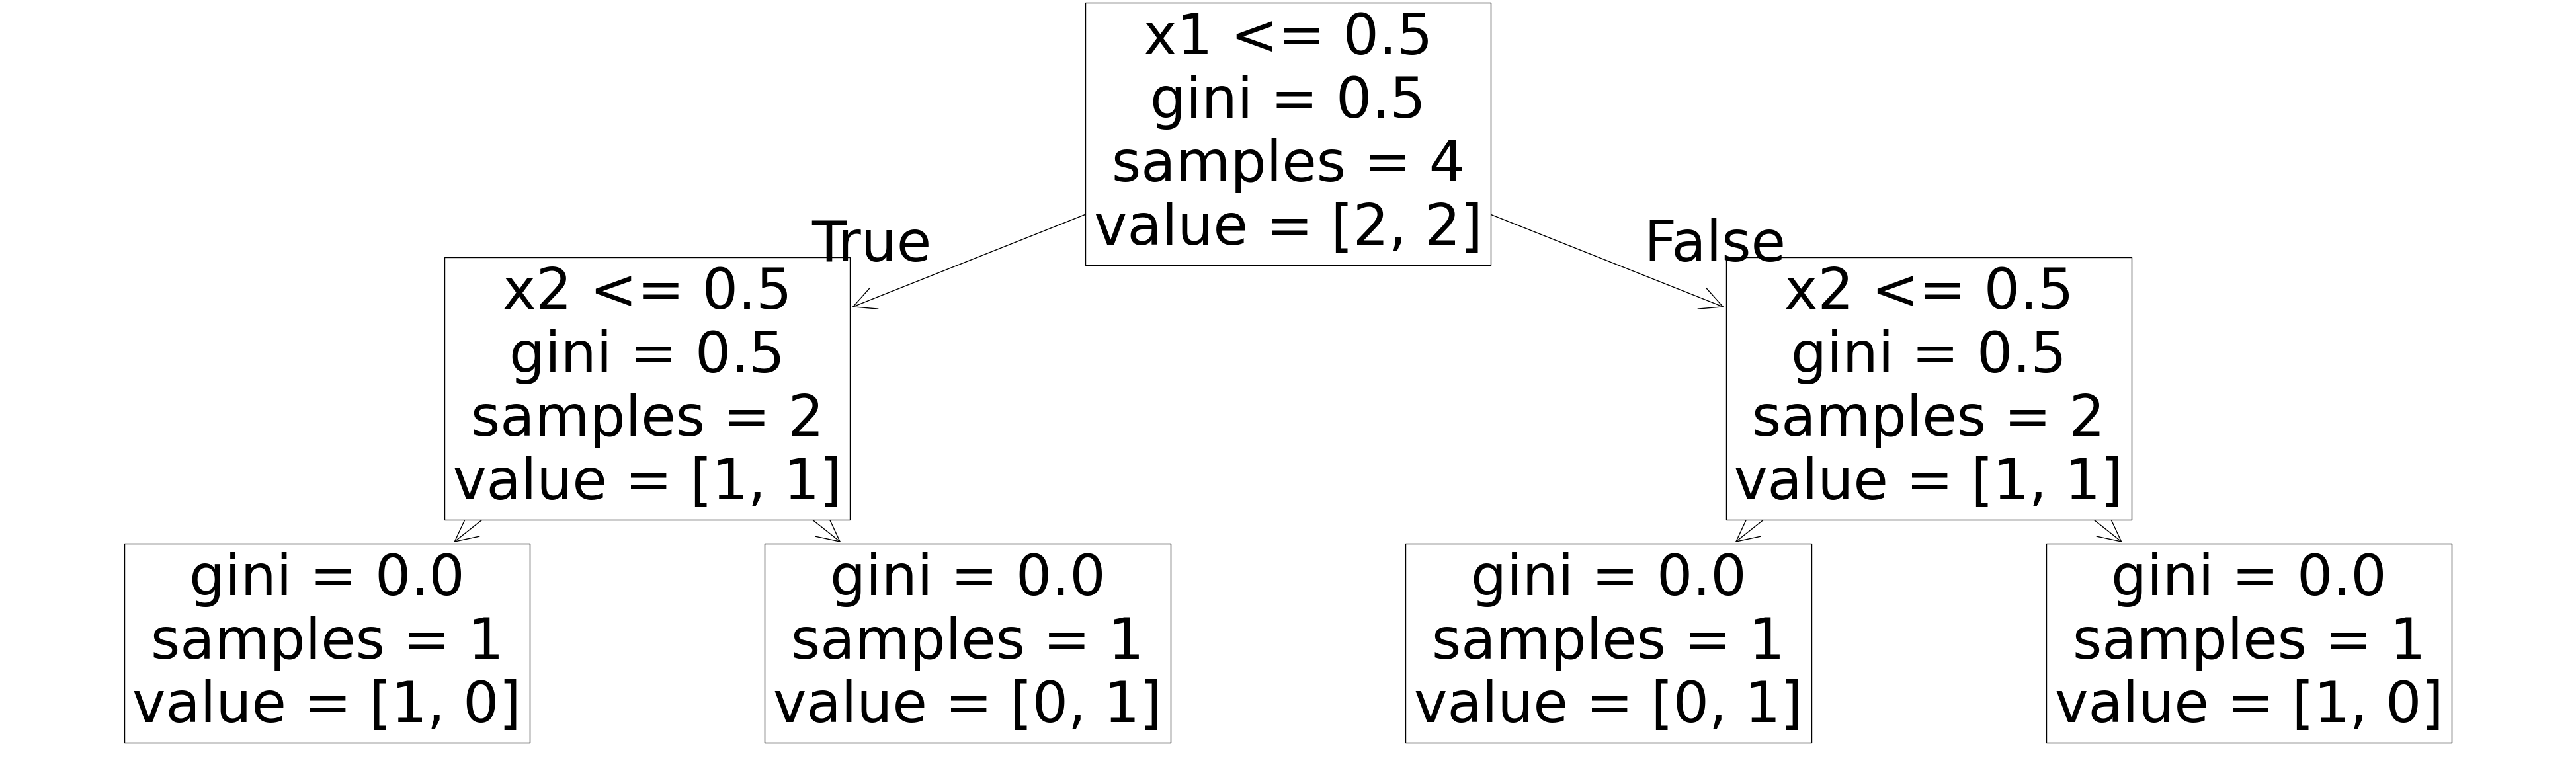

In [42]:
fig, ax = plt.subplots(figsize = (50, 15))
plot_tree(dtc, feature_names=['x1', 'x2'], ax=ax)
plt.show()

## Decision Tree XOR

In [43]:
data2 = pd.DataFrame([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
], columns=['x1', 'x2', 'y'])
data2

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


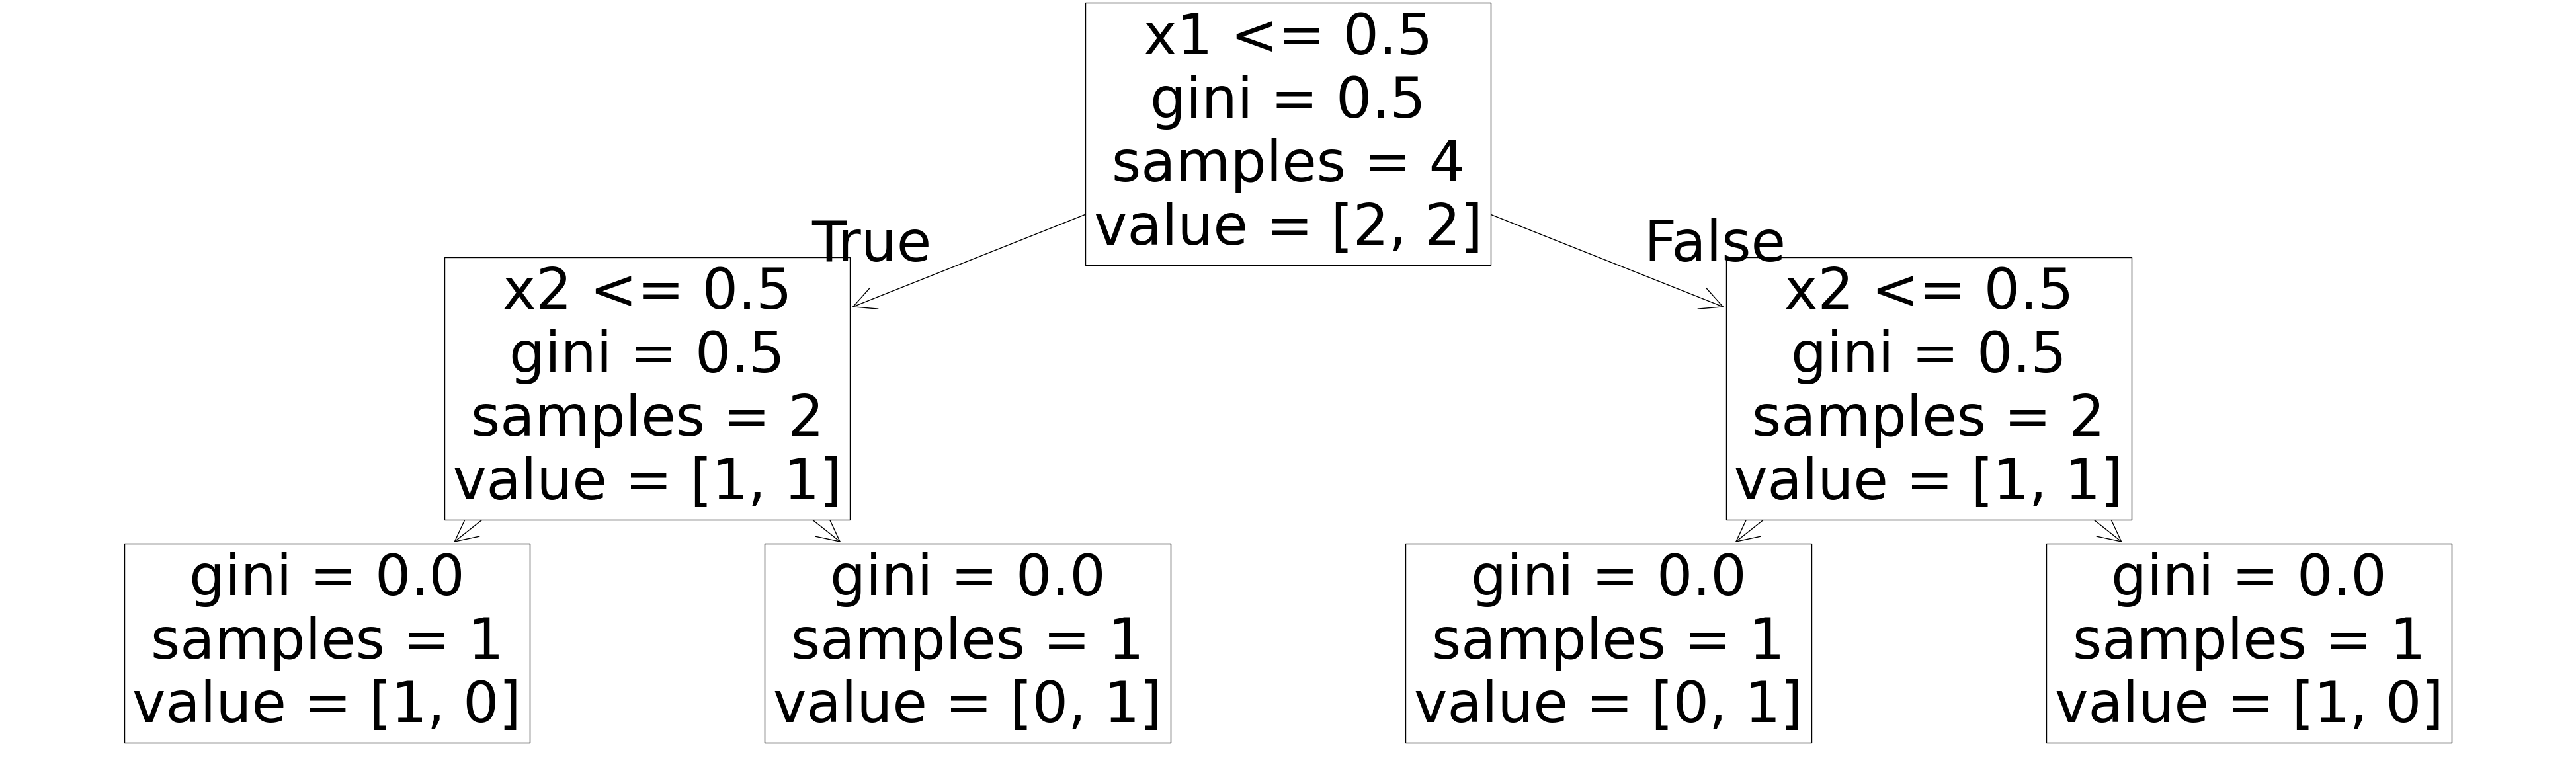

In [44]:
X = data2[['x1', 'x2']]
y = data2['y']
dtc = DecisionTreeClassifier()
dtc.fit(X, y)
fig, ax = plt.subplots(figsize = (50, 15))
plot_tree(dtc, feature_names=['x1', 'x2'], ax=ax)
plt.show()

## Bài toán (x1 and x2) or x3

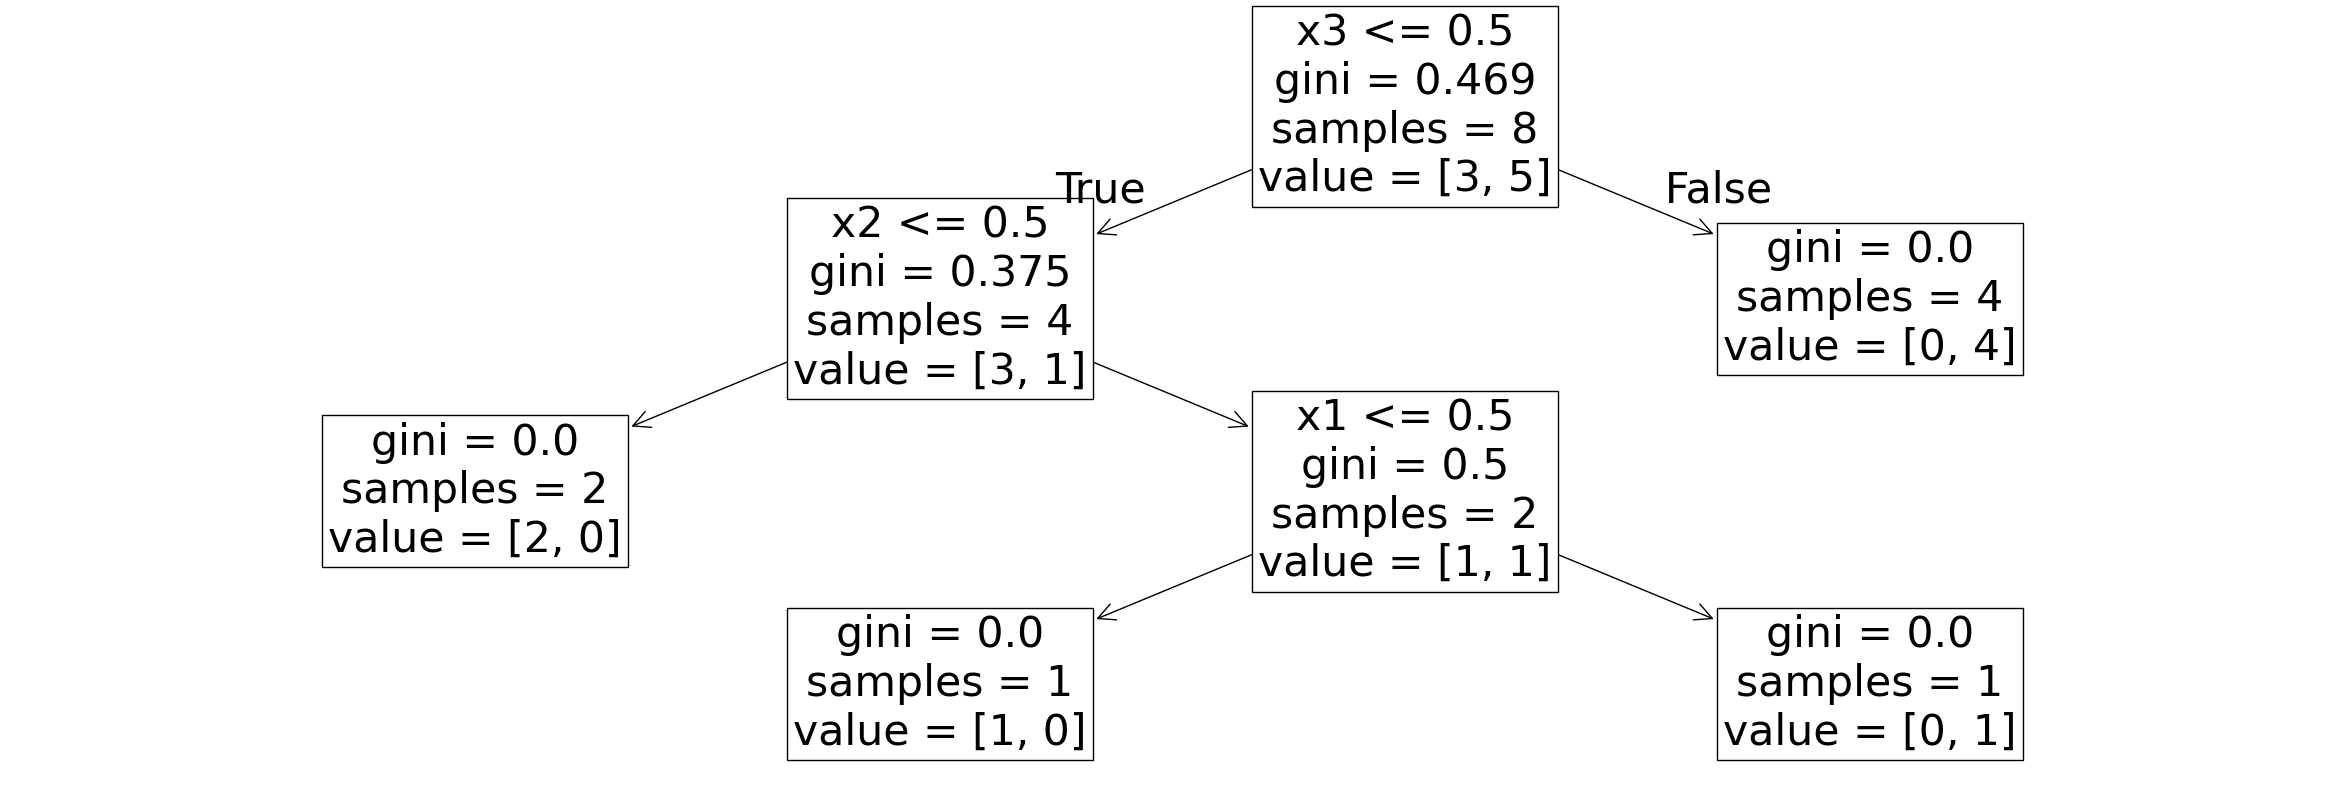

In [51]:
data3 = pd.DataFrame([
    [0, 0, 0, 0],
    [0, 0, 1, 1],
    [0, 1, 0, 0],
    [0, 1, 1, 1],
    [1, 0, 0, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 1],
    [1, 1, 1, 1]
], columns=['x1', 'x2', 'x3', 'y'])
X = data3[['x1', 'x2', 'x3']]
y = data3['y']
dtc = DecisionTreeClassifier()
dtc.fit(X, y)
plt.rcParams['figure.figsize'] = (30, 10)
plot_tree(dtc, feature_names=['x1', 'x2', 'x3'])
plt.show()

# Tính gini score
$$ gini_y = 1 - \sum{p_i^2} $$

In [68]:
colors = ['red', 'green', 'blue', 'red', 'blue']
# Nguyễn Tất Bảo Thiện
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
label = LabelEncoder()
abc = label.fit_transform(colors).reshape((5, 1))
#abc = label.fit_transform(colors)
oneHot = OneHotEncoder()
oneHot.fit_transform(abc).toarray()

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [69]:
colors = np.array(['red', 'green', 'blue', 'red', 'blue'])
oneHot = OneHotEncoder(sparse_output=False)
oneHot.fit_transform(colors.reshape((-1, 1)))

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [79]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split

In [80]:
df = pd.read_csv('data/hour.csv')
df.head(n=2)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40


# Loại bỏ các biến không dùng <b>instant<b>, <b>atemp<b>, <b>casual<b>, <b>registered<b>

In [81]:
df.drop(columns=['instant', 'atemp', 'casual', 'registered'], inplace=True)

In [82]:
df.head(n=2)

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40


In [83]:
df.rename(columns={'cnt': 'total_count', 'yr': 'year', 'hr': 'hour', 'mnth': 'month', 
                   'holiday': 'is_holiday','workingday': 'is_workingday', 'hum': 'humidity', 
                   'weathersit': 'weather_condition'
}, inplace=True)

In [84]:
df.head(n=2)

,dteday,season,year,month,hour,is_holiday,weekday,is_workingday,weather_condition,temp,humidity,windspeed,total_count
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40


In [85]:
X = df.drop(columns= ['dteday', 'total_count'])
y =  df['total_count']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [88]:
dtr = DecisionTreeRegressor(random_state=2026)
dtr.fit(X_train, y_train)
dtr.score(X_train, y_train), dtr.score(X_test, y_test)

(0.9999902500753987, 0.887871784839365)

In [ ]:
gscv = GridSearchCV(estimator=dtr, param_grid={
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [10, 11, 12, 13, 14],
    'min_samples_split': [18, 19, 20, 21, 22]
    }
)
gscv.fit(X_train, y_train)
gscv.best_score_, gscv.best_params_

(np.float64(0.9017360436167431),
 {'criterion': 'squared_error', 'max_depth': 14, 'min_samples_split': 19})

In [96]:
dtr = DecisionTreeRegressor(random_state=2026, criterion='squared_error', max_depth=13, min_samples_split=20)
dtr.fit(X_train, y_train)
dtr.score(X_train, y_train), dtr.score(X_test, y_test)

(0.9459311356428233, 0.90790973304522)

In [97]:
rfr = RandomForestRegressor(random_state=2026)
rfr.fit(X_train, y_train)
rfr.score(X_train, y_train), rfr.score(X_test, y_test)

(0.9919766545301271, 0.9437602526249784)

In [98]:
abr = AdaBoostRegressor(random_state=2026)
abr.fit(X_train, y_train)
abr.score(X_train, y_train), abr.score(X_test, y_test)

(0.6683835916513534, 0.6719371704446334)

In [112]:
df = pd.read_csv('data/Social_Network_Ads.xls')
df.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [114]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [120]:
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])

In [121]:
df.head(n=2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0


In [122]:
X = df.drop(columns= ['User ID', 'Purchased'])
y =  df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [123]:
dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train, y_train)
dtc.score(X_train, y_train), dtc.score(X_test, y_test)

(0.9966666666666667, 0.85)

In [126]:
gscv = GridSearchCV(estimator=dtc, param_grid={
    'criterion': ['entropy', 'gini'],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 3, 4, 5]
})
gscv.fit(X_test, y_test)
gscv.best_estimator_, gscv.best_params_

(DecisionTreeClassifier(criterion='entropy', max_depth=3),
 {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2})

In [127]:
dtc = DecisionTreeClassifier(criterion='entropy', max_depth = 5, min_samples_split = 2)
dtc.fit(X_train, y_train)
dtc.score(X_train, y_train), dtc.score(X_test, y_test)

(0.95, 0.83)

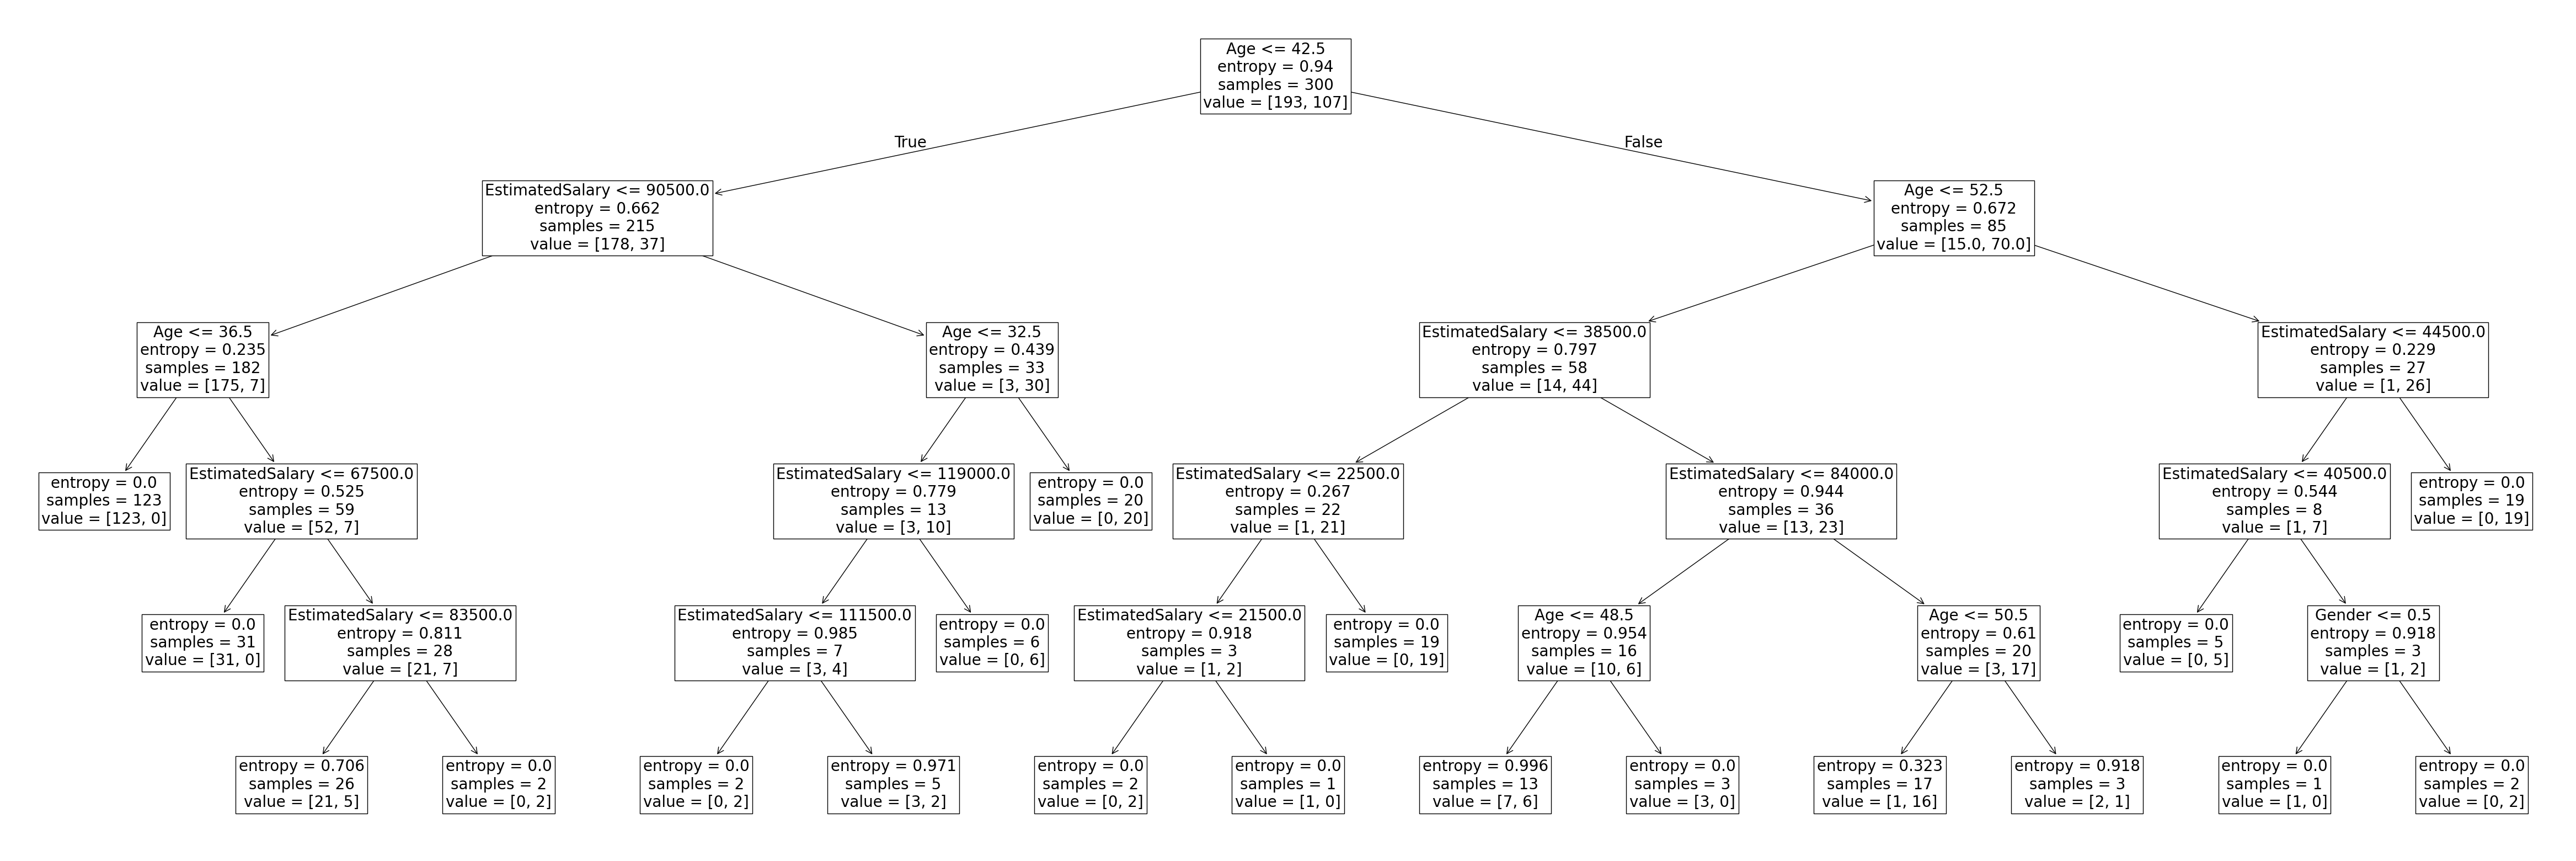

In [129]:
plt.rcParams['font.size'] = 36
fig, ax = plt.subplots(figsize = (60, 20))
plot_tree(dtc, ax=ax, feature_names= dtc.feature_names_in_, fontsize=20)
plt.show()

# PGS Nguyễn Trường Thịnh

In [130]:
scaler = StandardScaler()
cols_cont = ['Age', 'EstimatedSalary']
X_train[cols_cont] = scaler.fit_transform(X_train[cols_cont])
X_test[cols_cont] = scaler.transform(X_test[cols_cont])

In [131]:
dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train, y_train)
dtc.score(X_train, y_train), dtc.score(X_test, y_test)

(0.9966666666666667, 0.85)

In [132]:
y_pred = dtc.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[56  8]
 [ 7 29]]


In [133]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88        64
           1       0.78      0.81      0.79        36

    accuracy                           0.85       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.85      0.85      0.85       100



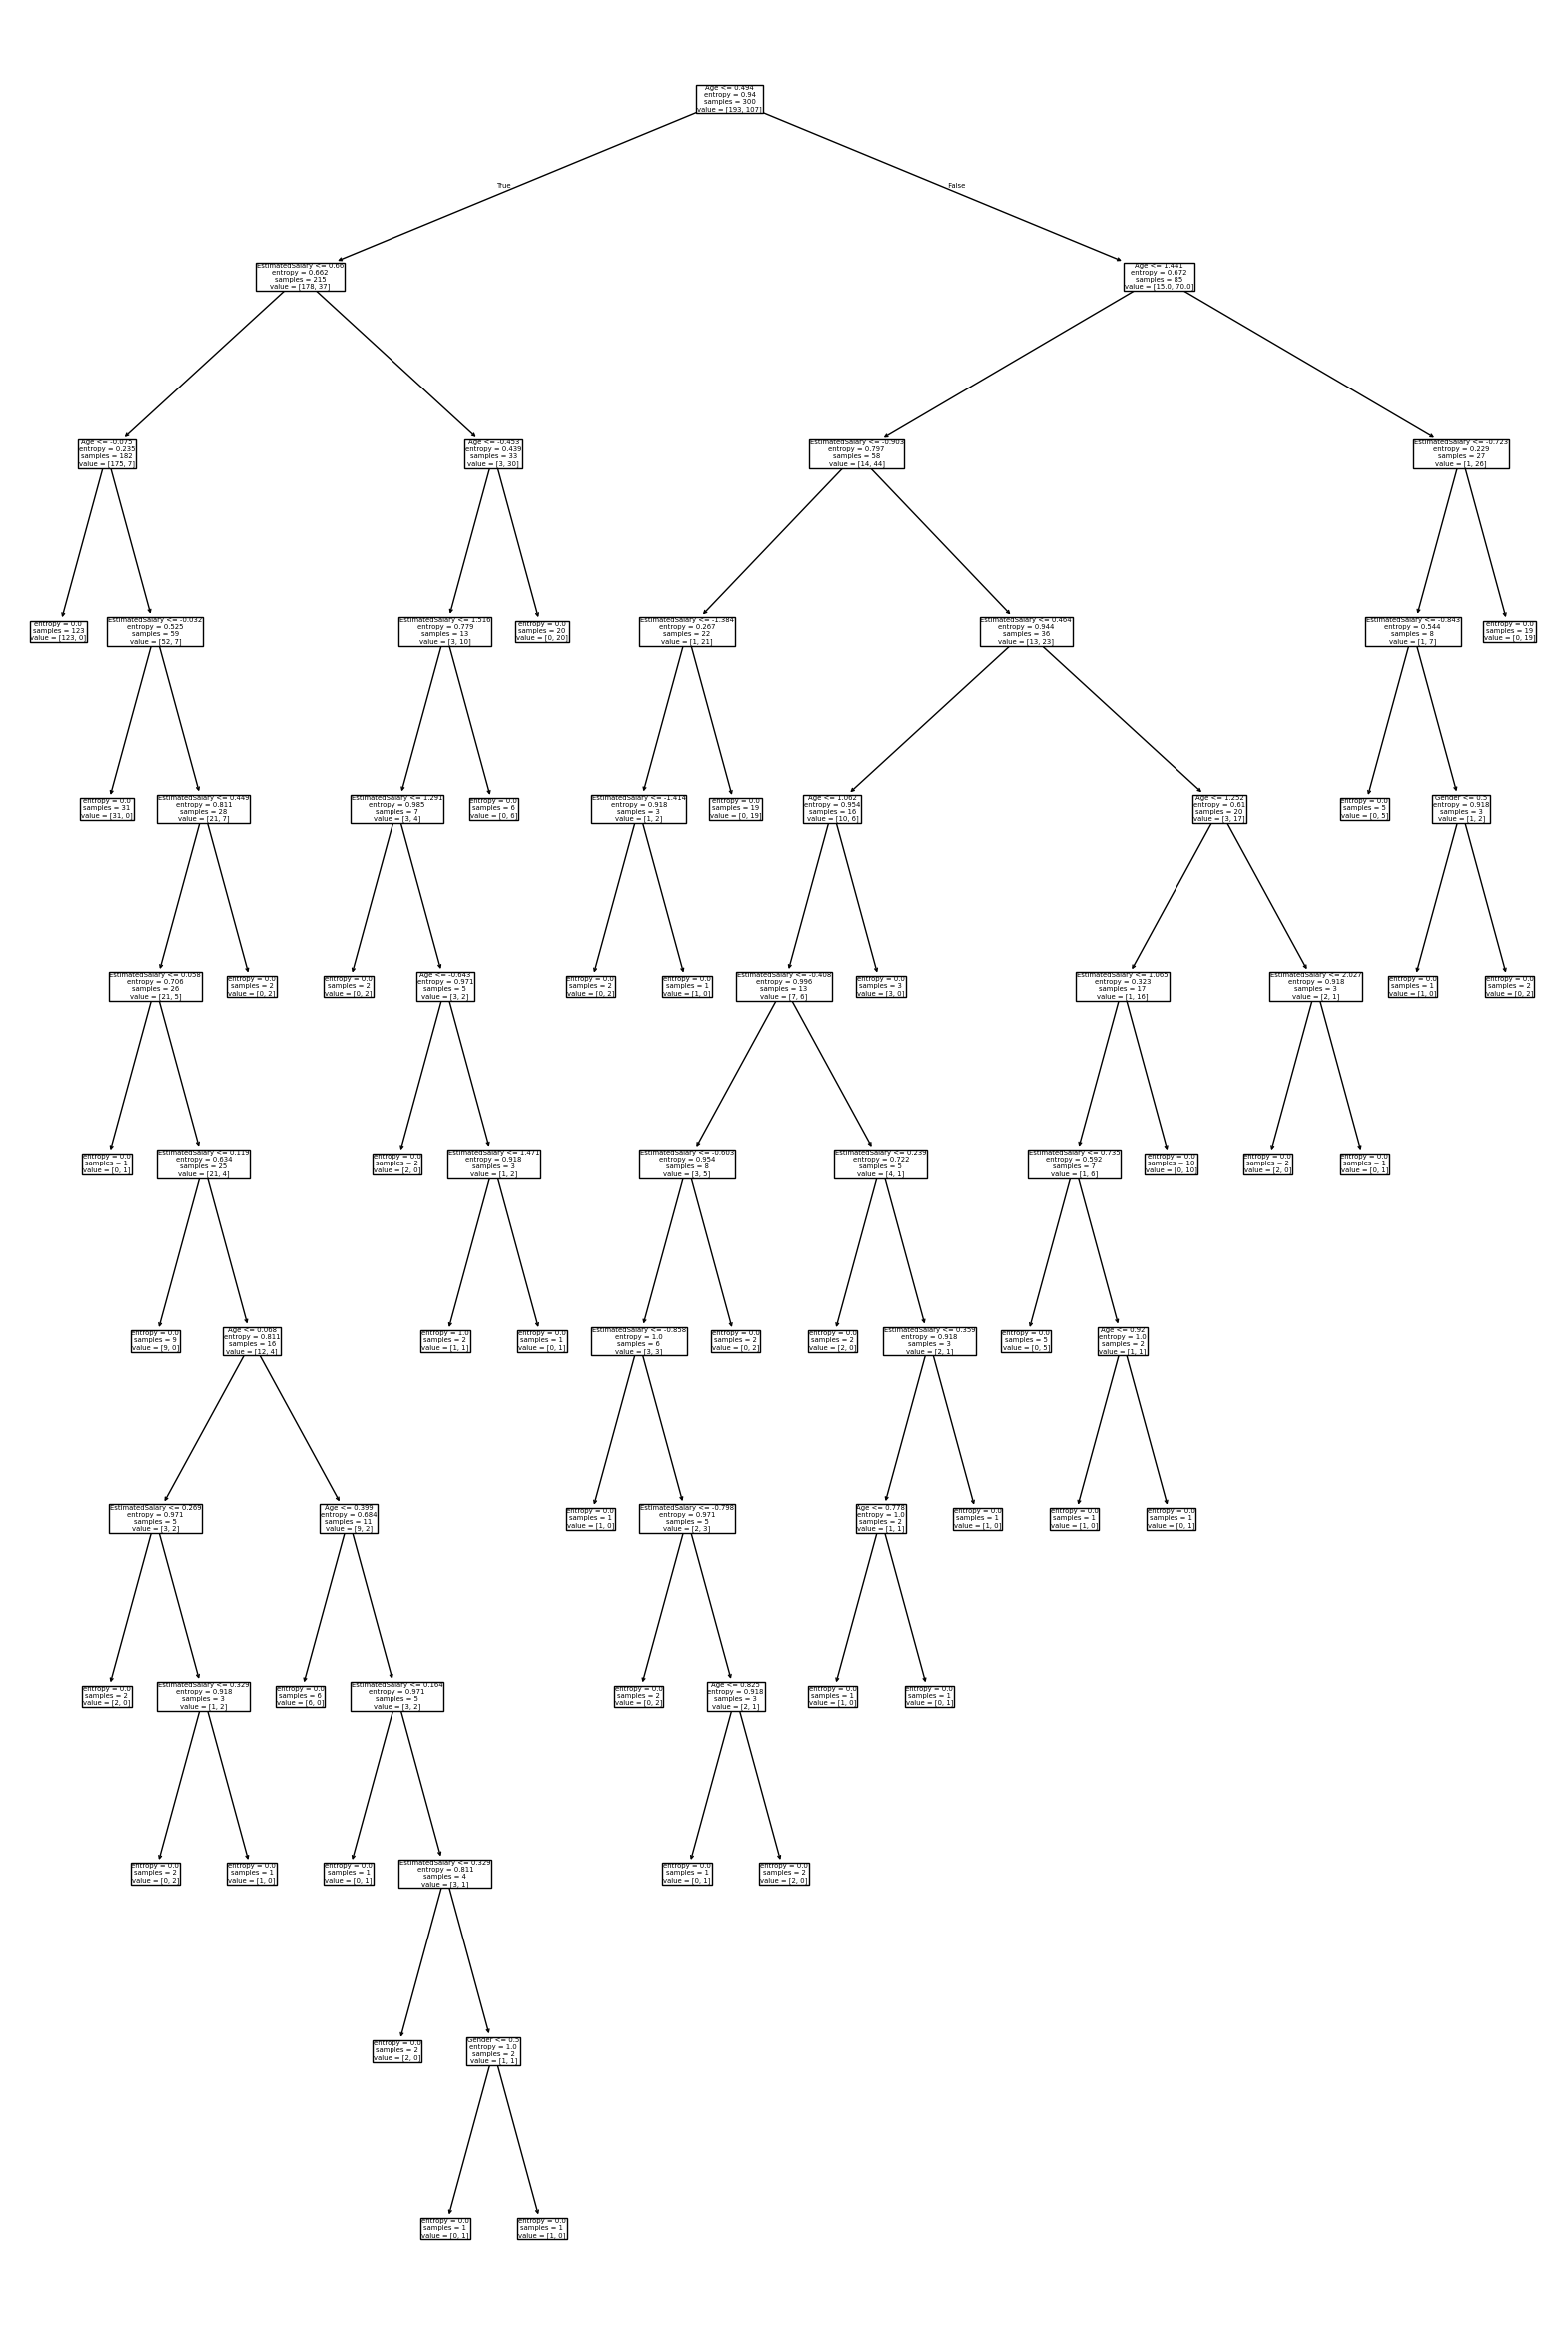

In [134]:
fig, ax = plt.subplots(figsize = (20, 30))
plot_tree(dtc, ax=ax, feature_names=dtc.feature_names_in_)
plt.show()